# Q1

In [1]:
import os
import random
import string
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageFont
from scipy import ndimage
import matplotlib.pyplot as plt
import cv2

random.seed(42)
np.random.seed(42)

In [12]:
BASE_DIR = os.path.dirname(os.getcwd())
DATA_DIR = os.path.join(BASE_DIR, 'data', 'captcha')
OUTPUT_DIR = os.path.join(BASE_DIR, 'outputs')

os.makedirs(os.path.join(DATA_DIR, 'generated_captchas'), exist_ok=True)
os.makedirs(os.path.join(DATA_DIR, 'noisy_captchas'), exist_ok=True)
os.makedirs(os.path.join(DATA_DIR, 'filtered_captchas'), exist_ok=True)

print(f"Data: {DATA_DIR}")
print(f"Outputs: {OUTPUT_DIR}")

Data: e:\University_Projects\Vision\Computer-Vision-Course\HW2\data\captcha
Outputs: e:\University_Projects\Vision\Computer-Vision-Course\HW2\outputs


In [13]:
def generate_random_text(length=4):
    characters = string.ascii_lowercase + string.digits
    return ''.join(random.choice(characters) for _ in range(length))

def create_captcha_image(text, size=(200, 80), font_size=50):
    image = Image.new('RGB', size, color='white')
    draw = ImageDraw.Draw(image)
    
    try:
        font = ImageFont.truetype("arial.ttf", font_size)
    except:
        font = ImageFont.load_default()
    
    bbox = draw.textbbox((0, 0), text, font=font)
    text_width = bbox[2] - bbox[0]
    text_height = bbox[3] - bbox[1]
    
    position = ((size[0] - text_width) // 2, (size[1] - text_height) // 2)
    
    draw.text(position, text, fill='black', font=font)
    
    return image

captcha_data = []

for i in range(1, 21):
    text = generate_random_text(4)
    
    image = create_captcha_image(text)
    
    filename = f"captcha_{text}.png"
    filepath = os.path.join(DATA_DIR, 'generated_captchas', filename)
    image.save(filepath)
    
    captcha_data.append({
        'id': i,
        'text': text,
        'filename': filename
    })
    
    print(f"Image {i:02d} generated: {text} -> {filename}")

print(f"\nAll 20 images were saved in {os.path.join(DATA_DIR, 'generated_captchas')}")

Image 01 generated: 8mtz -> captcha_8mtz.png
Image 02 generated: x272 -> captcha_x272.png
Image 03 generated: hpoe -> captcha_hpoe.png
Image 04 generated: vb9o -> captcha_vb9o.png
Image 05 generated: oaed -> captcha_oaed.png
Image 06 generated: oecv -> captcha_oecv.png
Image 07 generated: e6pr -> captcha_e6pr.png
Image 08 generated: 5n8i -> captcha_5n8i.png
Image 09 generated: 4p40 -> captcha_4p40.png
Image 10 generated: mgg1 -> captcha_mgg1.png
Image 11 generated: w103 -> captcha_w103.png
Image 12 generated: dgdz -> captcha_dgdz.png
Image 13 generated: vgpm -> captcha_vgpm.png
Image 14 generated: m82i -> captcha_m82i.png
Image 15 generated: 1lr3 -> captcha_1lr3.png
Image 16 generated: pe29 -> captcha_pe29.png
Image 17 generated: gd8a -> captcha_gd8a.png
Image 18 generated: fpk0 -> captcha_fpk0.png
Image 19 generated: 54nz -> captcha_54nz.png
Image 20 generated: dkya -> captcha_dkya.png

All 20 images were saved in e:\University_Projects\Vision\Computer-Vision-Course\HW2\data\captcha\g

In [14]:
df = pd.DataFrame(captcha_data)

csv_path = os.path.join(DATA_DIR, 'captcha_labels.csv')
df.to_csv(csv_path, index=False, encoding='utf-8')

df.head()

,id,text,filename
0,1,8mtz,captcha_8mtz.png
1,2,x272,captcha_x272.png
2,3,hpoe,captcha_hpoe.png
3,4,vb9o,captcha_vb9o.png
4,5,oaed,captcha_oaed.png


Noise was added to all images

All noisy images were saved in e:\University_Projects\Vision\Computer-Vision-Course\HW2\data\captcha\noisy_captchas


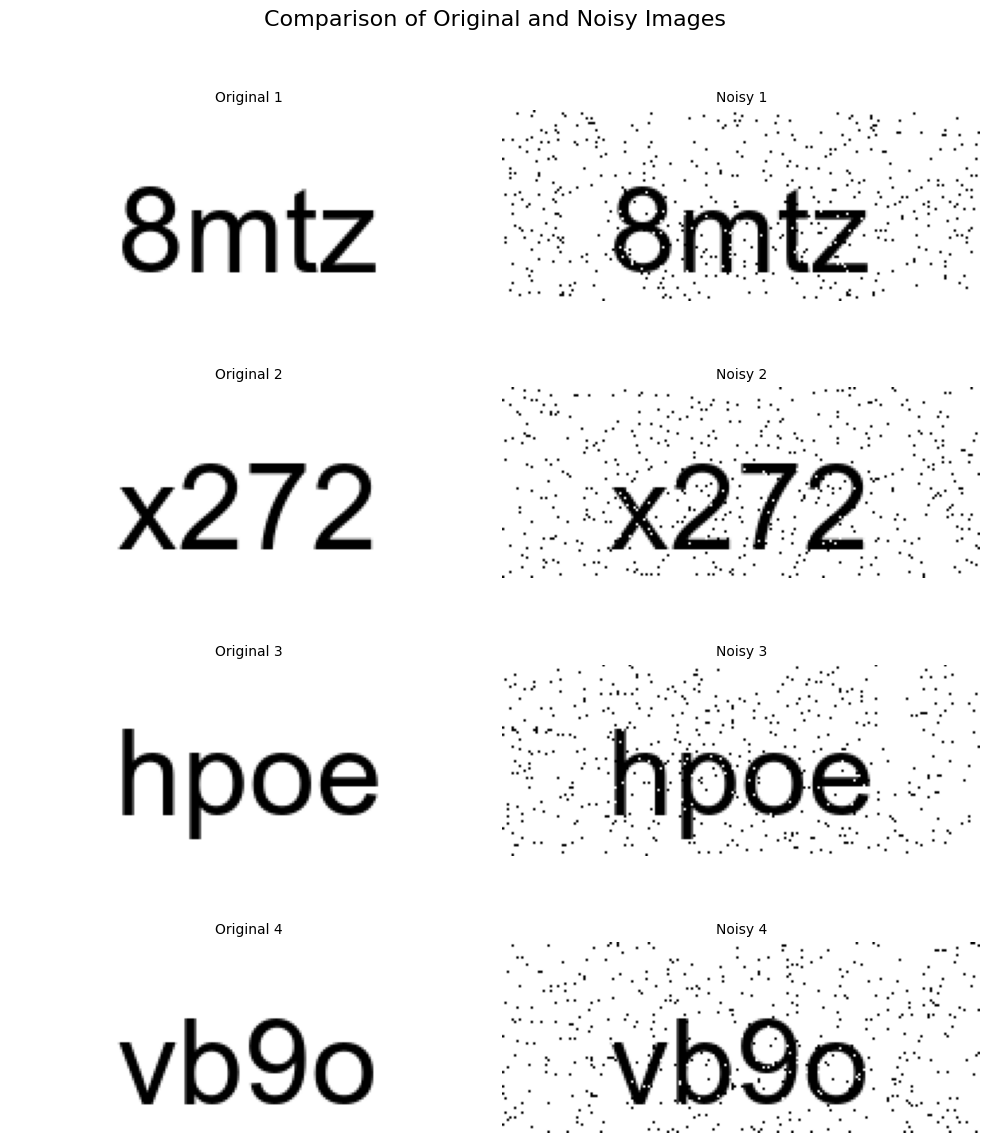

In [19]:
def add_salt_pepper_noise(image, salt_prob=0.03, pepper_prob=0.03):
    img_array = np.array(image)
    
    salt_mask = np.random.random(img_array.shape[:2]) < salt_prob
    img_array[salt_mask] = 255
    
    pepper_mask = np.random.random(img_array.shape[:2]) < pepper_prob
    img_array[pepper_mask] = 0
    
    return Image.fromarray(img_array)

for i in range(1, 21):
    filename = f"captcha_{captcha_data[i-1]['text']}.png"
    
    original_path = os.path.join(DATA_DIR, 'generated_captchas', filename)
    image = Image.open(original_path)
    
    noisy_image = add_salt_pepper_noise(image, salt_prob=0.03, pepper_prob=0.03)
    
    noisy_path = os.path.join(DATA_DIR, 'noisy_captchas', filename)
    noisy_image.save(noisy_path)
    
print(f"Noise was added to all images")

print(f"\nAll noisy images were saved in {os.path.join(DATA_DIR, 'noisy_captchas')}")

fig, axes = plt.subplots(4, 2, figsize=(10, 12))
fig.suptitle('Comparison of Original and Noisy Images', fontsize=16, y=0.995)

for idx in range(4):
    filename = f"captcha_{captcha_data[idx]['text']}.png"
    
    original = Image.open(os.path.join(DATA_DIR, 'generated_captchas', filename))
    noisy = Image.open(os.path.join(DATA_DIR, 'noisy_captchas', filename))
    
    axes[idx, 0].imshow(original, cmap='gray')
    axes[idx, 0].set_title(f'Original {idx+1}', fontsize=10)
    axes[idx, 0].axis('off')
    
    axes[idx, 1].imshow(noisy, cmap='gray')
    axes[idx, 1].set_title(f'Noisy {idx+1}', fontsize=10)
    axes[idx, 1].axis('off')

plt.tight_layout()
plt.show()

To remove salt-and-pepper noise, there are three main filters:

1. Median Filter (Best choice)
   - Robust against outliers
   - Preserves edges better
   - Ideal for salt-and-pepper noise

2. Mean Filter
   - Causes image blurring
   - Does not fully remove outlier noise

3. Gaussian Filter
   - Suitable for Gaussian noise
   - Less effective for salt-and-pepper noise

So we use the median filter to remove the noise.

In [20]:
def apply_median_filter(image, size=3):
    img_array = np.array(image)
    filtered = ndimage.median_filter(img_array, size=size)
    return Image.fromarray(filtered)

def apply_mean_filter(image, size=3):
    img_array = np.array(image)
    kernel = np.ones((size, size)) / (size * size)
    
    if len(img_array.shape) == 3:
        filtered = np.zeros_like(img_array)
        for i in range(3):
            filtered[:,:,i] = ndimage.convolve(img_array[:,:,i], kernel)
    else:
        filtered = ndimage.convolve(img_array, kernel)
    
    return Image.fromarray(filtered.astype(np.uint8))

def apply_gaussian_filter(image, sigma=1):
    img_array = np.array(image)
    filtered = ndimage.gaussian_filter(img_array, sigma=sigma)
    return Image.fromarray(filtered.astype(np.uint8))

Median filter applied to all images

All filtered images were saved in e:\University_Projects\Vision\Computer-Vision-Course\HW2\data\captcha\filtered_captchas


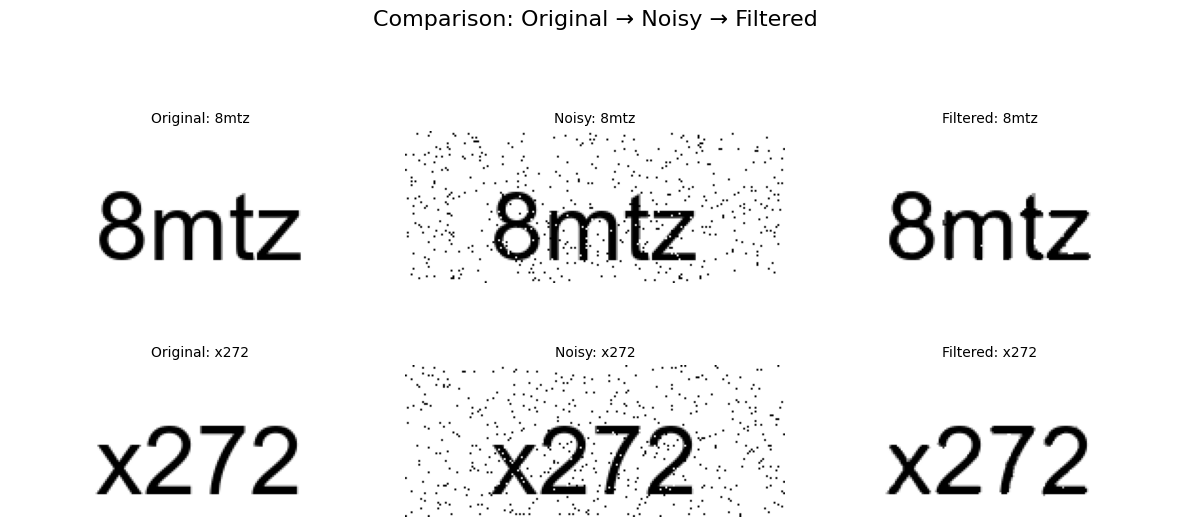

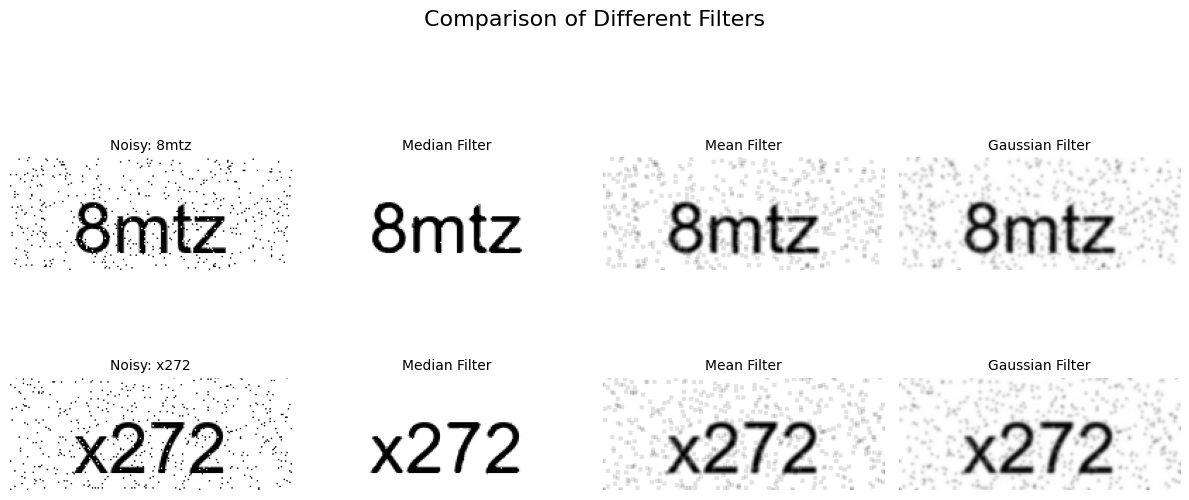

In [29]:
for i in range(1, 21):
    filename = f"captcha_{captcha_data[i-1]['text']}.png"
    
    noisy_path = os.path.join(DATA_DIR, 'noisy_captchas', filename)
    noisy_image = Image.open(noisy_path)
    
    filtered_image = apply_median_filter(noisy_image, size=3)
    
    filtered_path = os.path.join(DATA_DIR, 'filtered_captchas', filename)
    filtered_image.save(filtered_path)
    
print(f"Median filter applied to all images")
print(f"\nAll filtered images were saved in {os.path.join(DATA_DIR, 'filtered_captchas')}")

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
fig.suptitle('Comparison: Original → Noisy → Filtered', fontsize=16, y=0.995)

for idx in range(2):
    filename = f"captcha_{captcha_data[idx]['text']}.png"
    text = df[df['filename'] == filename]['text'].values[0]
    
    original = Image.open(os.path.join(DATA_DIR, 'generated_captchas', filename))
    noisy = Image.open(os.path.join(DATA_DIR, 'noisy_captchas', filename))
    filtered = Image.open(os.path.join(DATA_DIR, 'filtered_captchas', filename))
    
    axes[idx, 0].imshow(original, cmap='gray')
    axes[idx, 0].set_title(f'Original: {text}', fontsize=10)
    axes[idx, 0].axis('off')
    
    axes[idx, 1].imshow(noisy, cmap='gray')
    axes[idx, 1].set_title(f'Noisy: {text}', fontsize=10)
    axes[idx, 1].axis('off')
    
    axes[idx, 2].imshow(filtered, cmap='gray')
    axes[idx, 2].set_title(f'Filtered: {text}', fontsize=10)
    axes[idx, 2].axis('off')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle('Comparison of Different Filters', fontsize=16, y=0.995)

for idx in range(2):
    filename = f"captcha_{captcha_data[idx]['text']}.png"
    text = df[df['filename'] == filename]['text'].values[0]
    
    noisy = Image.open(os.path.join(DATA_DIR, 'noisy_captchas', filename))
    
    median_filtered = apply_median_filter(noisy, size=3)
    mean_filtered = apply_mean_filter(noisy, size=3)
    gaussian_filtered = apply_gaussian_filter(noisy, sigma=1)
    
    axes[idx, 0].imshow(noisy, cmap='gray')
    axes[idx, 0].set_title(f'Noisy: {text}', fontsize=10)
    axes[idx, 0].axis('off')
    
    axes[idx, 1].imshow(median_filtered, cmap='gray')
    axes[idx, 1].set_title(f'Median Filter', fontsize=10)
    axes[idx, 1].axis('off')
    
    axes[idx, 2].imshow(mean_filtered, cmap='gray')
    axes[idx, 2].set_title(f'Mean Filter', fontsize=10)
    axes[idx, 2].axis('off')
    
    axes[idx, 3].imshow(gaussian_filtered, cmap='gray')
    axes[idx, 3].set_title(f'Gaussian Filter', fontsize=10)
    axes[idx, 3].axis('off')

plt.tight_layout()
plt.show()

# Q2

In [10]:
def apply_blur_filter(image, kernel_size=5):
    img_array = np.array(image)
    
    blurred = cv2.blur(img_array, (kernel_size, kernel_size))
    
    return blurred

def apply_gaussian_blur(image, kernel_size=5, sigma=1.0):
    img_array = np.array(image)
    
    blurred = cv2.GaussianBlur(img_array, (kernel_size, kernel_size), sigma)
    
    return blurred

sample_noisy = Image.open(os.path.join(DATA_DIR, 'noisy', 'captcha_01.png'))

blur_3x3 = apply_blur_filter(sample_noisy, kernel_size=3)
blur_5x5 = apply_blur_filter(sample_noisy, kernel_size=5)
blur_7x7 = apply_blur_filter(sample_noisy, kernel_size=7)
gaussian_5x5 = apply_gaussian_blur(sample_noisy, kernel_size=5, sigma=1.0)
gaussian_7x7 = apply_gaussian_blur(sample_noisy, kernel_size=7, sigma=1.5)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Comparison of Blur Filters for Noise Removal', fontsize=16)

axes[0, 0].imshow(sample_noisy, cmap='gray')
axes[0, 0].set_title('Original Noisy Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(blur_3x3, cmap='gray')
axes[0, 1].set_title('Average Blur 3*3')
axes[0, 1].axis('off')

axes[0, 2].imshow(blur_5x5, cmap='gray')
axes[0, 2].set_title('Average Blur 5*5')
axes[0, 2].axis('off')

axes[1, 0].imshow(blur_7x7, cmap='gray')
axes[1, 0].set_title('Average Blur 7*7')
axes[1, 0].axis('off')

axes[1, 1].imshow(gaussian_5x5, cmap='gray')
axes[1, 1].set_title('Gaussian Blur 5*5 (σ=1.0)')
axes[1, 1].axis('off')

axes[1, 2].imshow(gaussian_7x7, cmap='gray')
axes[1, 2].set_title('Gaussian Blur 7*7 (σ=1.5)')
axes[1, 2].axis('off')

plt.tight_layout()
blur_comparison_path = os.path.join(OUTPUT_DIR, 'blur_filters_comparison.png')
plt.savefig(blur_comparison_path, dpi=150, bbox_inches='tight')
plt.close()

print(f"Blur filter comparison saved in {blur_comparison_path}")

print("\nApplying Gaussian 5*5 filter to all noisy images...")
denoised_dir = os.path.join(DATA_DIR, 'denoised')
os.makedirs(denoised_dir, exist_ok=True)

for i in range(1, 21):
    filename = f"captcha_{i:02d}.png"
    noisy_img = Image.open(os.path.join(DATA_DIR, 'noisy', filename))
    denoised = apply_gaussian_blur(noisy_img, kernel_size=5, sigma=1.0)
    
    Image.fromarray(denoised).save(os.path.join(denoised_dir, filename))

print(f"Filtered images saved in {denoised_dir}")

Blur filter comparison saved in e:\University_Projects\Vision\Computer-Vision-Course\HW2\outputs\blur_filters_comparison.png

Applying Gaussian 5*5 filter to all noisy images...
Filtered images saved in e:\University_Projects\Vision\Computer-Vision-Course\HW2\data\captcha\denoised


In [11]:
def apply_sharpening(image, method='unsharp_mask', amount=1.5):
    if isinstance(image, Image.Image):
        img_array = np.array(image)
    else:
        img_array = image.copy()
    
    if method == 'unsharp_mask':
        blurred = cv2.GaussianBlur(img_array, (5, 5), 1.0)
        sharpened = cv2.addWeighted(img_array, 1.0 + amount, blurred, -amount, 0)
        sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)
        
    elif method == 'laplacian':
        laplacian = cv2.Laplacian(img_array, cv2.CV_64F)
        sharpened = img_array - amount * laplacian
        sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)
    
    return sharpened

sample_denoised = Image.open(os.path.join(denoised_dir, 'captcha_01.png'))

sharp_unsharp_1 = apply_sharpening(sample_denoised, method='unsharp_mask', amount=1.0)
sharp_unsharp_2 = apply_sharpening(sample_denoised, method='unsharp_mask', amount=2.0)
sharp_laplacian = apply_sharpening(sample_denoised, method='laplacian', amount=0.5)

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
fig.suptitle('Comparison of Sharpening Methods', fontsize=16)

axes[0, 0].imshow(sample_denoised, cmap='gray')
axes[0, 0].set_title('Denoised Image (Blurred)')
axes[0, 0].axis('off')

axes[0, 1].imshow(sharp_unsharp_1, cmap='gray')
axes[0, 1].set_title('Unsharp Mask (amount=1.0)')
axes[0, 1].axis('off')

axes[1, 0].imshow(sharp_unsharp_2, cmap='gray')
axes[1, 0].set_title('Unsharp Mask (amount=2.0)')
axes[1, 0].axis('off')

axes[1, 1].imshow(sharp_laplacian, cmap='gray')
axes[1, 1].set_title('Laplacian Sharpening (amount=0.5)')
axes[1, 1].axis('off')

plt.tight_layout()
sharp_comparison_path = os.path.join(OUTPUT_DIR, 'sharpening_comparison.png')
plt.savefig(sharp_comparison_path, dpi=150, bbox_inches='tight')
plt.close()

print(f"Sharpening methods comparison saved in {sharp_comparison_path}")

print("\nApplying Unsharp Masking to all images...")
sharpened_dir = os.path.join(DATA_DIR, 'sharpened')
os.makedirs(sharpened_dir, exist_ok=True)

for i in range(1, 21):
    filename = f"captcha_{i:02d}.png"
    denoised_img = Image.open(os.path.join(denoised_dir, filename))
    sharpened = apply_sharpening(denoised_img, method='unsharp_mask', amount=2)
    
    Image.fromarray(sharpened).save(os.path.join(sharpened_dir, filename))

print(f"Sharpened images saved in {sharpened_dir}")


Sharpening methods comparison saved in e:\University_Projects\Vision\Computer-Vision-Course\HW2\outputs\sharpening_comparison.png

Applying Unsharp Masking to all images...
Sharpened images saved in e:\University_Projects\Vision\Computer-Vision-Course\HW2\data\captcha\sharpened


In [12]:
def binarize_and_clean(image, threshold_method='otsu', min_component_size=50):
    if isinstance(image, Image.Image):
        img_array = np.array(image)
    else:
        img_array = image.copy()
    
    if len(img_array.shape) == 3:
        img_array = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
    
    if threshold_method == 'otsu':
        _, binary = cv2.threshold(img_array, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    elif threshold_method == 'adaptive':
        binary = cv2.adaptiveThreshold(img_array, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                       cv2.THRESH_BINARY, 11, 2)
    else:
        _, binary = cv2.threshold(img_array, threshold_method, 255, cv2.THRESH_BINARY)
    
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary, connectivity=8)
    
    cleaned = np.zeros_like(binary)
    
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if area >= min_component_size:
            cleaned[labels == i] = 255
    
    return binary, cleaned, num_labels - 1

sample_sharp = Image.open(os.path.join(sharpened_dir, 'captcha_01.png'))

binary_otsu, cleaned_otsu, num_comp_otsu = binarize_and_clean(sample_sharp, 'otsu', min_component_size=30)
binary_adaptive, cleaned_adaptive, num_comp_adaptive = binarize_and_clean(sample_sharp, 'adaptive', min_component_size=30)
binary_fixed, cleaned_fixed, num_comp_fixed = binarize_and_clean(sample_sharp, 128, min_component_size=30)

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
fig.suptitle('Comparison of Binarization and Cleaning Methods', fontsize=16)

axes[0, 0].imshow(sample_sharp, cmap='gray')
axes[0, 0].set_title('Sharpened Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(binary_otsu, cmap='gray')
axes[0, 1].set_title(f'Otsu Binary ({num_comp_otsu} components)')
axes[0, 1].axis('off')

axes[0, 2].imshow(cleaned_otsu, cmap='gray')
axes[0, 2].set_title('Otsu Cleaned (min_size=30)')
axes[0, 2].axis('off')

axes[1, 0].imshow(sample_sharp, cmap='gray')
axes[1, 0].set_title('Sharpened Image')
axes[1, 0].axis('off')

axes[1, 1].imshow(binary_adaptive, cmap='gray')
axes[1, 1].set_title(f'Adaptive Binary ({num_comp_adaptive} components)')
axes[1, 1].axis('off')

axes[1, 2].imshow(cleaned_adaptive, cmap='gray')
axes[1, 2].set_title('Adaptive Cleaned (min_size=30)')
axes[1, 2].axis('off')

axes[2, 0].imshow(sample_sharp, cmap='gray')
axes[2, 0].set_title('Sharpened Image')
axes[2, 0].axis('off')

axes[2, 1].imshow(binary_fixed, cmap='gray')
axes[2, 1].set_title(f'Fixed(128) Binary ({num_comp_fixed} components)')
axes[2, 1].axis('off')

axes[2, 2].imshow(cleaned_fixed, cmap='gray')
axes[2, 2].set_title('Fixed Cleaned (min_size=30)')
axes[2, 2].axis('off')

plt.tight_layout()
binary_comparison_path = os.path.join(OUTPUT_DIR, 'binarization_comparison.png')
plt.savefig(binary_comparison_path, dpi=150, bbox_inches='tight')
plt.close()

print(f"Binarization methods comparison saved in {binary_comparison_path}")

print("\nApplying Otsu binarization and cleaning to all images...")
cleaned_dir = os.path.join(DATA_DIR, 'cleaned')
os.makedirs(cleaned_dir, exist_ok=True)

for i in range(1, 21):
    filename = f"captcha_{i:02d}.png"
    sharp_img = Image.open(os.path.join(sharpened_dir, filename))
    _, cleaned, _ = binarize_and_clean(sharp_img, 'otsu', min_component_size=30)
    
    Image.fromarray(cleaned).save(os.path.join(cleaned_dir, filename))

print(f"Cleaned binary images saved in {cleaned_dir}")

Binarization methods comparison saved in e:\University_Projects\Vision\Computer-Vision-Course\HW2\outputs\binarization_comparison.png

Applying Otsu binarization and cleaning to all images...
Cleaned binary images saved in e:\University_Projects\Vision\Computer-Vision-Course\HW2\data\captcha\cleaned


In [13]:
print("Creating overall comparison image of preprocessing stages")

fig = plt.figure(figsize=(20, 12))

for idx in range(4):
    filename = f"captcha_{idx+1:02d}.png"
    
    original = Image.open(os.path.join(DATA_DIR, 'original', filename))
    noisy = Image.open(os.path.join(DATA_DIR, 'noisy', filename))
    denoised = Image.open(os.path.join(denoised_dir, filename))
    sharpened = Image.open(os.path.join(sharpened_dir, filename))
    cleaned = Image.open(os.path.join(cleaned_dir, filename))
    
    row = idx
    
    ax1 = fig.add_subplot(4, 5, row*5 + 1)
    ax1.imshow(original, cmap='gray')
    if idx == 0:
        ax1.set_title('Original', fontsize=12, fontweight='bold')
    ax1.set_ylabel(f'Sample {idx+1}', fontsize=11)
    ax1.axis('off')
    
    ax2 = fig.add_subplot(4, 5, row*5 + 2)
    ax2.imshow(noisy, cmap='gray')
    if idx == 0:
        ax2.set_title('Noisy', fontsize=12, fontweight='bold')
    ax2.axis('off')
    
    ax3 = fig.add_subplot(4, 5, row*5 + 3)
    ax3.imshow(denoised, cmap='gray')
    if idx == 0:
        ax3.set_title('Denoised', fontsize=12, fontweight='bold')
    ax3.axis('off')
    
    ax4 = fig.add_subplot(4, 5, row*5 + 4)
    ax4.imshow(sharpened, cmap='gray')
    if idx == 0:
        ax4.set_title('Sharpened', fontsize=12, fontweight='bold')
    ax4.axis('off')
    
    ax5 = fig.add_subplot(4, 5, row*5 + 5)
    ax5.imshow(cleaned, cmap='gray')
    if idx == 0:
        ax5.set_title('Cleaned', fontsize=12, fontweight='bold')
    ax5.axis('off')

fig.suptitle('Complete Preprocessing Pipeline for CAPTCHA Images', fontsize=18, fontweight='bold')
plt.tight_layout()
preprocessing_path = os.path.join(OUTPUT_DIR, 'preprocessing_pipeline.png')
plt.savefig(preprocessing_path, dpi=150, bbox_inches='tight')
plt.close()

Creating overall comparison image of preprocessing stages


# Q3